In [1]:
%pip install numpy matplotlib
%pip install pyttsx3

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pyttsx3

from scipy.io import wavfile
from IPython.display import Audio, display
from pathlib import Path

In [5]:
import pyttsx3
from pathlib import Path

text = (
    "People love Japan for its incredible contrast between ancient "
    "traditions and hyper-modernity, world-class culinary scene, "
    "exceptional safety, and deep-rooted culture of respect. "
    "It's a place that continually captivates visitors and residents alike."
)

output_file = Path.cwd() / "japan_voice.wav"

# Remove an incomplete file from the previous attempt
if output_file.exists():
    output_file.unlink()

# Use the Windows speech engine
engine = pyttsx3.init(driverName="sapi5")
engine.setProperty("rate", 145)
engine.setProperty("volume", 1.0)

engine.save_to_file(text, str(output_file))
engine.runAndWait()
engine.stop()

print("Voice created:", output_file)  

Voice created: C:\Users\khaled\japan_voice.wav


In [9]:
from IPython.display import Audio, display

display(Audio(filename="japan_voice.wav"))

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [15]:
sample_rate, samples = wavfile.read("japan_voice.wav")

print("Sample rate:", sample_rate)
print("Shape:", samples.shape)
print("Data type:", samples.dtype)

Sample rate: 22050
Shape: (355144,)
Data type: int16


In [17]:
# Convert stereo audio into mono
if samples.ndim == 2:
    samples = samples.mean(axis=1)

# Convert samples to decimal numbers
samples = samples.astype(np.float32)

# Normalize between -1 and 1
maximum = np.max(np.abs(samples))

if maximum > 0:
    samples = samples / maximum

duration = len(samples) / sample_rate

print("Duration:", round(duration, 2), "seconds")
print("Number of samples:", len(samples))

Duration: 16.11 seconds
Number of samples: 355144


In [19]:
def build_visualization(samples, sample_rate):
    samples = np.asarray(samples, dtype=float).flatten()

    if samples.size == 0:
        raise ValueError("Audio samples cannot be empty.")

    if sample_rate <= 0:
        raise ValueError("Sample rate must be positive.")

    # Output 1: waveform
    waveform = samples.copy()

    frame_size = 1024
    hop_size = 512

    # Handle very short audio
    if len(samples) < frame_size:
        analysis_samples = np.pad(
            samples,
            (0, frame_size - len(samples))
        )
    else:
        analysis_samples = samples

    spectrogram_frames = []
    voice_bar_values = []

    # Divide the audio into small frames
    for start in range(
        0,
        len(analysis_samples) - frame_size + 1,
        hop_size
    ):
        frame = analysis_samples[start:start + frame_size]

        # Output 2: frequency information
        windowed_frame = frame * np.hanning(frame_size)
        spectrum = np.abs(np.fft.rfft(windowed_frame))
        spectrogram_frames.append(spectrum)

        # Output 3: volume information
        rms = np.sqrt(np.mean(frame ** 2))
        voice_bar_values.append(rms)

    spectrogram = np.array(spectrogram_frames).T
    spectrogram = 20 * np.log10(spectrogram + 1e-10)

    voice_bars = np.array(voice_bar_values)

    return {
        "waveform": waveform,
        "spectrogram": spectrogram,
        "voice_bars": voice_bars,
    }

In [21]:
result = build_visualization(samples, sample_rate)

print("Waveform shape:", result["waveform"].shape)
print("Spectrogram shape:", result["spectrogram"].shape)
print("Voice bars shape:", result["voice_bars"].shape)

Waveform shape: (355144,)
Spectrogram shape: (513, 692)
Voice bars shape: (692,)


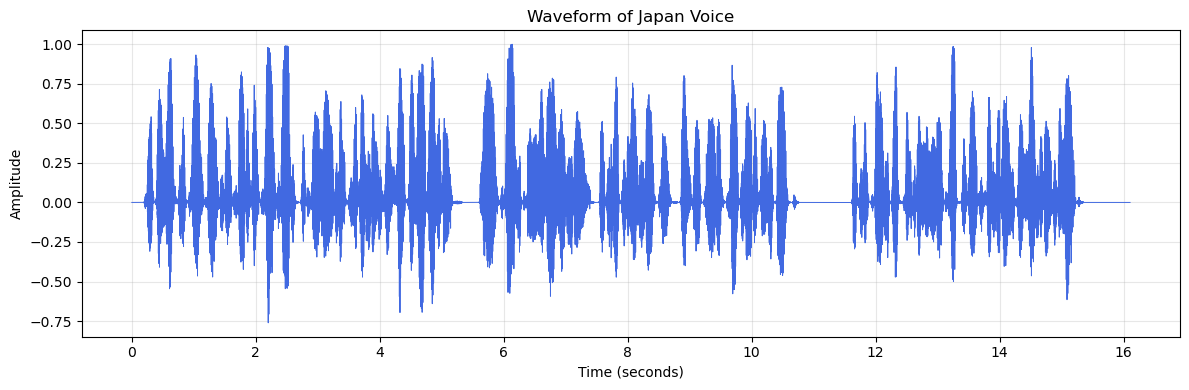

In [23]:
time = np.arange(len(result["waveform"])) / sample_rate

plt.figure(figsize=(12, 4))
plt.plot(time, result["waveform"], color="royalblue", linewidth=0.7)

plt.title("Waveform of Japan Voice")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("japan_voice_waveform.png", dpi=300)
plt.show()

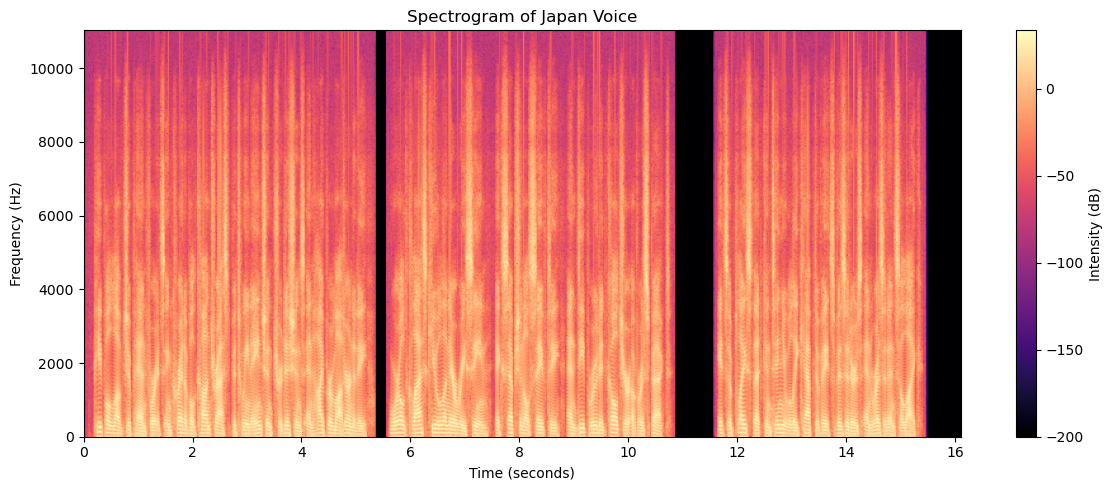

In [25]:
plt.figure(figsize=(12, 5))

plt.imshow(
    result["spectrogram"],
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=[0, duration, 0, sample_rate / 2]
)

plt.title("Spectrogram of Japan Voice")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Intensity (dB)")
plt.tight_layout()

plt.savefig("japan_voice_spectrogram.png", dpi=300)
plt.show()

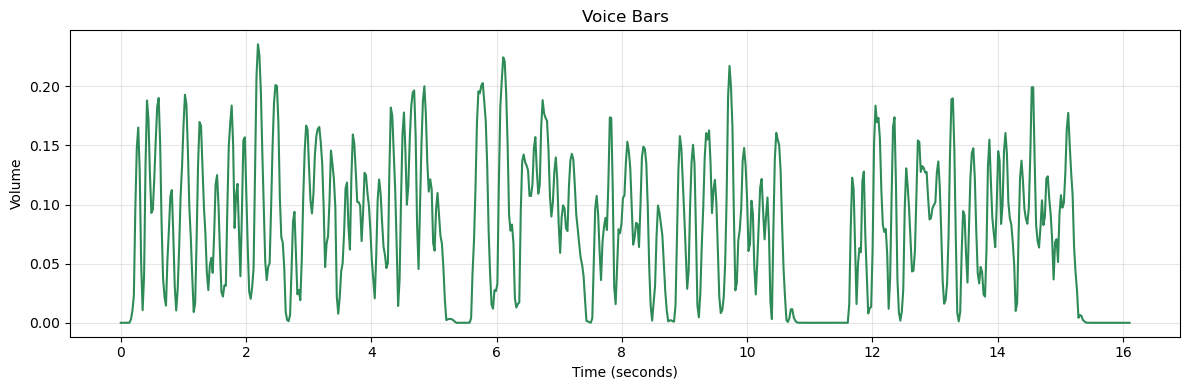

In [27]:
bar_times = np.linspace(0, duration, len(result["voice_bars"]))

plt.figure(figsize=(12, 4))
plt.plot(bar_times, result["voice_bars"], color="seagreen")

plt.title("Voice Bars")
plt.xlabel("Time (seconds)")
plt.ylabel("Volume")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("japan_voice_bars.png", dpi=300)
plt.show()